# Earth Systems Playground — Wildfire Series
## Part 4: Synthesis

**What this part does.** Pulls together every sub-region from Parts 1–3 and
asks two questions across all of them at once, neither of which could be
answered from inside a single part:

1. **Why do some sub-regions show a weak/absent climate signal?** Two
   competing explanations have come up repeatedly (Türkiye's coast in Part
   1, Mediterranean south Iberia in Part 2, the Baltic states in Part 3):
   *managed* (strong fire-suppression infrastructure absorbs the climate
   signal before it becomes burned area) vs. *underpowered* (fire is rare
   enough in that sub-region that no climate metric has enough variance to
   correlate with). This part tests both against a rough proxy — GDP per
   capita for "managed," and the coefficient of variation of fire density
   for "underpowered."
2. **Is there a real 25-year directional trend in any of these ecosystems,
   once compared on the same normalized scale?** Each part plotted its own
   region's absolute burned-area trend; none were ever placed side by side.

**A standing caveat carried over from Part 3**: every correlation reported
in Parts 1 and 2 was published before the leave-one-out check that broke
the Baltic states' result in Part 3 existed as a standing practice. Rather
than asking you to go back and re-run those two notebooks separately,
Section 3 below recomputes each sub-region's climate metric from scratch,
right here, and applies the same leave-one-out check to all eight at once
-- so this notebook is the single place where every number in the series
has actually been stress-tested the same way.

This notebook is self-contained (rebuilds all eight sub-region geometries
from scratch) since Parts 1–3 ran in separate sessions and their
dataframes weren't persisted.


In [2]:
# --- Imports ---
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()


## 1. Rebuild all eight sub-region geometries

Same GAUL/LSIB sources and (corrected) province names as Parts 1–3. If any of these need adjustment, re-check against the printed name lists from the original parts before trusting a filter here.

In [3]:
countries = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
gaul = ee.FeatureCollection("FAO/GAUL/2015/level1")

def region_area_km2(geom):
    return geom.area(maxError=1000).getInfo() / 1e6

# --- Part 1: Eastern Mediterranean ---
p1_countries = countries.filter(ee.Filter.inList("country_na", ["Turkey", "Greece", "Cyprus"]))
greece_geom = p1_countries.filter(ee.Filter.eq("country_na", "Greece")).geometry()
cyprus_geom = p1_countries.filter(ee.Filter.eq("country_na", "Cyprus")).geometry()

tr_provinces = gaul.filter(ee.Filter.eq("ADM0_NAME", "Turkey"))
tr_coastal_names = ["Canakkale", "Balikesir", "Izmir", "Aydin", "Mugla", "Antalya", "Mersin", "Adana", "Hatay"]
turkey_geom_full = p1_countries.filter(ee.Filter.eq("country_na", "Turkey")).geometry()
turkey_coastal_geom = tr_provinces.filter(ee.Filter.inList("ADM1_NAME", tr_coastal_names)).geometry().dissolve()
turkey_interior_geom = turkey_geom_full.difference(turkey_coastal_geom, ee.ErrorMargin(1000))

# --- Part 2: Iberian Peninsula (corrected accented GAUL names) ---
es_regions = gaul.filter(ee.Filter.eq("ADM0_NAME", "Spain"))
pt_regions = gaul.filter(ee.Filter.eq("ADM0_NAME", "Portugal"))

med_south_names = ["Andaluc\u00eda", "Regi\u00f3n de Murcia", "Comunitat Valenciana", "Catalu\u00f1a/Catalunya", "Illes Balears"]
atlantic_nw_es_names = ["Galicia"]
atlantic_nw_pt_names = ["Viana Do Castelo", "Braga", "Porto", "Aveiro", "Braganca", "Vila Real", "Viseu", "Guarda", "Coimbra", "Leiria"]

med_south_geom = es_regions.filter(ee.Filter.inList("ADM1_NAME", med_south_names)).geometry().dissolve()
atlantic_nw_geom = (es_regions.filter(ee.Filter.inList("ADM1_NAME", atlantic_nw_es_names))
                     .merge(pt_regions.filter(ee.Filter.inList("ADM1_NAME", atlantic_nw_pt_names)))
                     .geometry().dissolve())

# --- Part 3: Scandinavia / Baltic ---
p3_countries = countries.filter(ee.Filter.inList("country_na", ["Sweden", "Finland", "Norway", "Estonia", "Latvia", "Lithuania"]))
nordic_geom = p3_countries.filter(ee.Filter.inList("country_na", ["Sweden", "Finland", "Norway"])).geometry().dissolve()
baltic_geom = p3_countries.filter(ee.Filter.inList("country_na", ["Estonia", "Latvia", "Lithuania"])).geometry().dissolve()

all_subregions = {
    "Greece": greece_geom,
    "Cyprus": cyprus_geom,
    "Turkey (coastal belt)": turkey_coastal_geom,
    "Turkey (interior)": turkey_interior_geom,
    "Atlantic/Central-North Iberia": atlantic_nw_geom,
    "Mediterranean south Iberia": med_south_geom,
    "Nordic boreal core": nordic_geom,
    "Baltic states": baltic_geom,
}

# Which "part" and ecosystem each sub-region belongs to, for later grouping/plots
ecosystem_lookup = {
    "Greece": "Eastern Mediterranean", "Cyprus": "Eastern Mediterranean",
    "Turkey (coastal belt)": "Eastern Mediterranean", "Turkey (interior)": "Eastern Mediterranean",
    "Atlantic/Central-North Iberia": "Iberian Peninsula", "Mediterranean south Iberia": "Iberian Peninsula",
    "Nordic boreal core": "Scandinavia/Baltic", "Baltic states": "Scandinavia/Baltic",
}


## 2. Fire density and its year-to-year variance, all eight sub-regions

Same `summer_fire_pixel_count` logic as every previous part. This is the piece none of the earlier notebooks computed across all sub-regions at once -- the coefficient of variation (CV = std/mean) here is the "underpowered" side of the two competing explanations.

⚠️ Eight sub-regions × 25 years = 200 `getInfo()` calls. This will take a while.

In [4]:
def summer_fire_pixel_count(year, geom):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("MODIS/061/MOD14A1")
             .filterDate(start, end)
             .select("FireMask"))
    fire_any = col.map(lambda img: img.gte(7)).sum().gt(0)
    stats_ = fire_any.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geom, scale=1000, maxPixels=1e10
    )
    return stats_.get("FireMask")

years = list(range(2001, 2026))
records = []
for label, geom in all_subregions.items():
    area_km2 = region_area_km2(geom)
    for y in years:
        fire_m2 = summer_fire_pixel_count(y, geom).getInfo()
        records.append({
            "subregion": label,
            "ecosystem": ecosystem_lookup[label],
            "year": y,
            "fire_area_km2": (fire_m2 or 0) / 1e6,
            "region_area_km2": area_km2,
        })

df_all = pd.DataFrame(records)
df_all["fire_density_pct"] = df_all["fire_area_km2"] / df_all["region_area_km2"] * 100
df_all.head()


,subregion,ecosystem,year,fire_area_km2,region_area_km2,fire_density_pct
0,Greece,Eastern Mediterranean,2001,1272.317275,131773.673734,0.965532
1,Greece,Eastern Mediterranean,2002,399.844560,131773.673734,0.303433
2,Greece,Eastern Mediterranean,2003,587.480155,131773.673734,0.445825
3,Greece,Eastern Mediterranean,2004,763.795000,131773.673734,0.579626
4,Greece,Eastern Mediterranean,2005,421.592819,131773.673734,0.319937


In [5]:
# --- Coefficient of variation per sub-region: the "underpowered" signal ---
cv_table = (df_all.groupby("subregion")["fire_density_pct"]
            .agg(["mean", "std"])
            .assign(cv=lambda d: d["std"] / d["mean"]))
cv_table = cv_table.reset_index()
cv_table


,subregion,mean,std,cv
0,Atlantic/Central-North Iberia,2.674274,2.191140,0.819340
1,Baltic states,0.057205,0.101660,1.777137
2,Cyprus,0.434524,0.361044,0.830895
3,Greece,0.668812,0.568936,0.850668
4,Mediterranean south Iberia,0.391914,0.335790,0.856796
5,Nordic boreal core,0.029597,0.016955,0.572848
6,Turkey (coastal belt),1.097857,0.488978,0.445393
7,Turkey (interior),0.711899,0.389123,0.546599


## 3. Climate drivers + leave-one-out robustness check, all eight sub-regions

Rather than copying the r/p values Parts 1-2 already reported and trusting them, this section recomputes each sub-region's climate metric from scratch and runs the same leave-one-out check that broke the Baltic states' result in Part 3 -- on every sub-region, not just the ones that already looked suspicious. Metric choice matches what each part established as appropriate for that region: fixed 35°C extreme-heat days for the Eastern Mediterranean (Part 1's original metric), relative (region's own p90) extreme-heat days for Iberia and the boreal sub-regions (Parts 2-3), plus longest dry spell for the boreal sub-regions specifically (Part 3).

⚠️ This is the most expensive cell in the whole series so far -- eight sub-regions, up to three metrics each, 25 years apiece, plus the dry-spell metric's `iterate()` cost for the two boreal sub-regions. Consider running this section separately and taking a break.

In [6]:
def extreme_heat_days_fixed(year, geom, threshold_c=35):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("temperature_2m_max"))
    hot_day_count = col.map(lambda img: img.subtract(273.15).gt(threshold_c)).sum()
    val = hot_day_count.reduceRegion(reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9)
    return val.get("temperature_2m_max")

def build_heat_baseline(geom, start_year=2001, end_year=2025, percentile=90):
    baseline_col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
                     .filter(ee.Filter.calendarRange(6, 9, "month"))
                     .filter(ee.Filter.calendarRange(start_year, end_year, "year"))
                     .select("temperature_2m_max"))
    return baseline_col.reduce(ee.Reducer.percentile([percentile])).rename("threshold")

def extreme_heat_days_relative(year, geom, threshold_img):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("temperature_2m_max"))
    hot_day_count = col.map(lambda img: img.gt(threshold_img)).sum()
    val = hot_day_count.reduceRegion(reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9)
    return val.get("temperature_2m_max")

def summer_precip_total(year, geom):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("total_precipitation_sum"))
    val = col.sum().reduceRegion(reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9)
    return val.get("total_precipitation_sum")

def longest_dry_spell(year, geom, precip_threshold_m=0.001):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("total_precipitation_sum")
             .sort("system:time_start"))
    img_list = col.toList(col.size())
    init = ee.Image(0).rename("streak").addBands(ee.Image(0).rename("maxstreak")).clip(geom)

    def accumulate(img, prev):
        img = ee.Image(img); prev = ee.Image(prev)
        streak = prev.select("streak"); maxstreak = prev.select("maxstreak")
        is_dry = img.lt(precip_threshold_m)
        new_streak = streak.add(1).multiply(is_dry)
        new_max = maxstreak.max(new_streak)
        return new_streak.rename("streak").addBands(new_max.rename("maxstreak"))

    result = ee.Image(img_list.iterate(accumulate, init))
    val = result.select("maxstreak").reduceRegion(reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9)
    return val.get("maxstreak")

# Which metric(s) apply to which sub-region, matching each part's original choice
metric_plan = {
    "Greece": ["heat_fixed", "precip"],
    "Cyprus": ["heat_fixed", "precip"],
    "Turkey (coastal belt)": ["heat_fixed", "precip"],
    "Turkey (interior)": ["heat_fixed", "precip"],
    "Atlantic/Central-North Iberia": ["heat_relative", "precip"],
    "Mediterranean south Iberia": ["heat_relative", "precip"],
    "Nordic boreal core": ["heat_relative", "dry_spell"],
    "Baltic states": ["heat_relative", "dry_spell"],
}


In [7]:
# --- Compute every metric for every sub-region that needs it ---
climate_records = []
heat_baselines_cache = {}

for label, geom in all_subregions.items():
    needed = metric_plan[label]
    if "heat_relative" in needed:
        heat_baselines_cache[label] = build_heat_baseline(geom)

    baseline_precip_vals = []
    for y in years:
        row = {"subregion": label, "year": y}
        if "heat_fixed" in needed:
            row["heat_days"] = extreme_heat_days_fixed(y, geom).getInfo()
        if "heat_relative" in needed:
            row["heat_days"] = extreme_heat_days_relative(y, geom, heat_baselines_cache[label]).getInfo()
        if "precip" in needed:
            row["precip_m"] = summer_precip_total(y, geom).getInfo()
        if "dry_spell" in needed:
            row["dry_spell_days"] = longest_dry_spell(y, geom).getInfo()
        climate_records.append(row)

df_climate_all = pd.DataFrame(climate_records)

# precipitation anomaly, per sub-region, same pattern as Parts 1-2
if "precip_m" in df_climate_all.columns:
    baseline_precip = df_climate_all.groupby("subregion")["precip_m"].transform("mean")
    df_climate_all["precip_anomaly_pct"] = (df_climate_all["precip_m"] - baseline_precip) / baseline_precip * 100

df_climate_all = df_climate_all.merge(
    df_all[["subregion", "year", "fire_density_pct"]], on=["subregion", "year"]
)
df_climate_all.head()


,subregion,year,heat_days,precip_m,dry_spell_days,precip_anomaly_pct,fire_density_pct
0,Greece,2001,3.438952,0.085881,NaN,-42.072197,0.965532
1,Greece,2002,2.774023,0.220581,NaN,48.784109,0.303433
2,Greece,2003,2.795779,0.119091,NaN,-19.672164,0.445825
3,Greece,2004,1.629337,0.130569,NaN,-11.929616,0.579626
4,Greece,2005,2.140289,0.148897,NaN,0.432830,0.319937


In [8]:
# --- Leave-one-out check, every sub-region x metric combination ---
def leave_one_out(df, label, metric_col, target_col="fire_density_pct"):
    sub = df[(df["subregion"] == label) & df[metric_col].notna()]
    if len(sub) < 5:
        return None
    extreme_yr = sub.loc[sub[metric_col].idxmax(), "year"]
    sub_excl = sub[sub["year"] != extreme_yr]
    r_full, p_full = stats.pearsonr(sub[metric_col], sub[target_col])
    r_excl, p_excl = stats.pearsonr(sub_excl[metric_col], sub_excl[target_col])
    fragile = abs(r_full - r_excl) > 0.25
    return {
        "subregion": label, "metric": metric_col,
        "r_full": round(r_full, 2), "p_full": round(p_full, 3),
        "extreme_year": int(extreme_yr),
        "r_excl": round(r_excl, 2), "p_excl": round(p_excl, 3),
        "fragile": fragile,
    }

metric_cols_present = [c for c in ["heat_days", "precip_anomaly_pct", "dry_spell_days"] if c in df_climate_all.columns]

loo_results = []
for label in all_subregions:
    for metric_col in metric_cols_present:
        result = leave_one_out(df_climate_all, label, metric_col)
        if result is not None:
            loo_results.append(result)

df_loo = pd.DataFrame(loo_results)
df_loo


,subregion,metric,r_full,p_full,extreme_year,r_excl,p_excl,fragile
0,Greece,heat_days,0.56,0.004,2021,0.57,0.004,False
1,Greece,precip_anomaly_pct,-0.22,0.297,2023,-0.37,0.077,False
2,Cyprus,heat_days,0.31,0.134,2024,0.47,0.022,False
3,Cyprus,precip_anomaly_pct,-0.52,0.008,2009,-0.49,0.014,False
4,Turkey (coastal belt),heat_days,-0.04,0.868,2024,0.09,0.667,False
5,Turkey (coastal belt),precip_anomaly_pct,-0.39,0.052,2014,-0.31,0.146,False
6,Turkey (interior),heat_days,-0.21,0.313,2025,-0.17,0.434,False
7,Turkey (interior),precip_anomaly_pct,0.27,0.193,2014,0.36,0.083,False
8,Atlantic/Central-North Iberia,heat_days,0.64,0.001,2025,0.59,0.002,False
9,Atlantic/Central-North Iberia,precip_anomaly_pct,-0.50,0.011,2023,-0.46,0.025,False


## 4. GDP per capita proxy, and the two-hypothesis comparison

GDP figures: Eurostat real GDP per capita, 2023 (\u20ac), a single consistent source across all countries. **Caveat, stated plainly**: this is a country-level proxy applied to sub-national regions -- Turkey's coastal belt and interior get the *same* GDP value, as do both Iberian sub-regions' host countries where they don't split cleanly. With 8 sub-regions drawing on only ~9 distinct country values (several repeated), this is an illustrative comparison, not a statistical test with real degrees of freedom. Presenting it as more than that would repeat the exact mistake Part 3 just corrected.

For each sub-region, the "primary" correlation used below is whichever metric has the strongest **post-leave-one-out** |r| -- not the strongest raw r, since Section 3 exists precisely to stop raw r from being trusted at face value.

In [9]:
gdp_per_capita_eur_2023 = {
    "Norway": 71870, "Sweden": 44620, "Finland": 36760, "Cyprus": 29080,
    "Spain": 25620, "Greece": 19460, "Portugal": 19250, "Lithuania": 15330,
    "Estonia": 15250, "Turkey": 14010, "Latvia": 13300,
}

subregion_to_gdp = {
    "Greece": gdp_per_capita_eur_2023["Greece"],
    "Cyprus": gdp_per_capita_eur_2023["Cyprus"],
    "Turkey (coastal belt)": gdp_per_capita_eur_2023["Turkey"],
    "Turkey (interior)": gdp_per_capita_eur_2023["Turkey"],
    "Atlantic/Central-North Iberia": np.mean([gdp_per_capita_eur_2023["Spain"], gdp_per_capita_eur_2023["Portugal"]]),
    "Mediterranean south Iberia": gdp_per_capita_eur_2023["Spain"],
    "Nordic boreal core": np.mean([gdp_per_capita_eur_2023["Sweden"], gdp_per_capita_eur_2023["Finland"], gdp_per_capita_eur_2023["Norway"]]),
    "Baltic states": np.mean([gdp_per_capita_eur_2023["Estonia"], gdp_per_capita_eur_2023["Latvia"], gdp_per_capita_eur_2023["Lithuania"]]),
}

cv_table["gdp_per_capita_eur"] = cv_table["subregion"].map(subregion_to_gdp)

# Pick each sub-region's strongest POST-LOO |r| as its "primary" signal
df_loo["abs_r_excl"] = df_loo["r_excl"].abs()
primary = df_loo.loc[df_loo.groupby("subregion")["abs_r_excl"].idxmax()]
primary = primary[["subregion", "metric", "r_excl", "p_excl", "fragile"]].rename(
    columns={"r_excl": "r", "p_excl": "p"}
)

summary = cv_table.merge(primary, on="subregion", how="left")
summary["abs_r"] = summary["r"].abs()
summary


,subregion,mean,std,cv,gdp_per_capita_eur,metric,r,p,fragile,abs_r
0,Atlantic/Central-North Iberia,2.674274,2.191140,0.819340,22435.000000,heat_days,0.59,0.002,False,0.59
1,Baltic states,0.057205,0.101660,1.777137,14626.666667,heat_days,0.27,0.208,False,0.27
2,Cyprus,0.434524,0.361044,0.830895,29080.000000,precip_anomaly_pct,-0.49,0.014,False,0.49
3,Greece,0.668812,0.568936,0.850668,19460.000000,heat_days,0.57,0.004,False,0.57
4,Mediterranean south Iberia,0.391914,0.335790,0.856796,25620.000000,precip_anomaly_pct,-0.32,0.124,False,0.32
5,Nordic boreal core,0.029597,0.016955,0.572848,51083.333333,heat_days,0.49,0.015,False,0.49
6,Turkey (coastal belt),1.097857,0.488978,0.445393,14010.000000,precip_anomaly_pct,-0.31,0.146,False,0.31
7,Turkey (interior),0.711899,0.389123,0.546599,14010.000000,precip_anomaly_pct,0.36,0.083,False,0.36


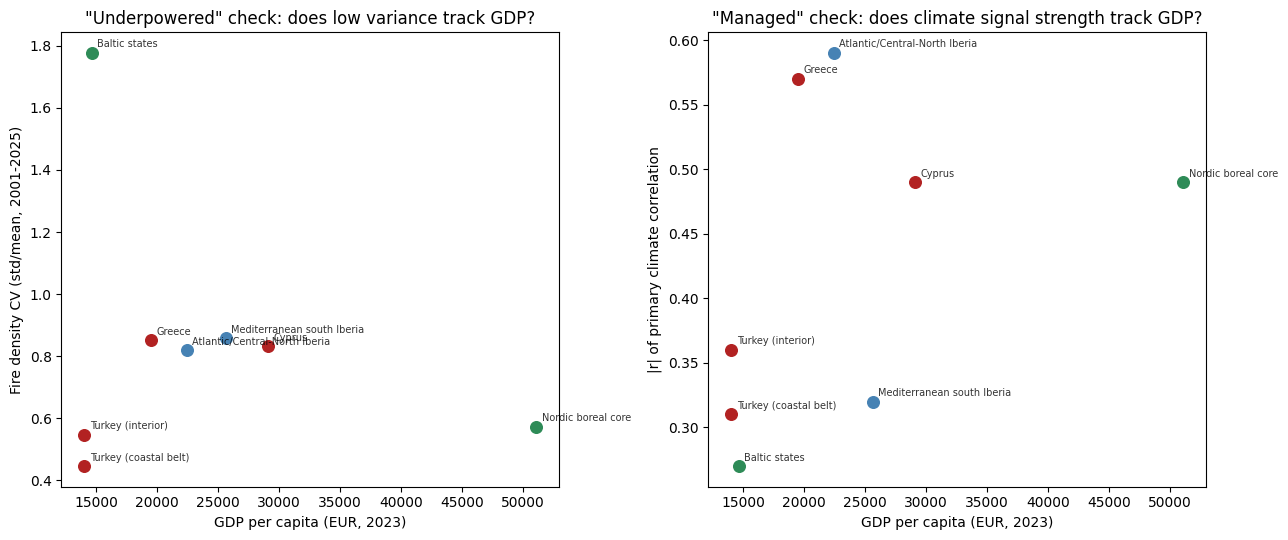

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for _, row in summary.iterrows():
    color = "firebrick" if "Eastern" in ecosystem_lookup.get(row["subregion"], "") else (
        "steelblue" if "Iberia" in row["subregion"] or "Iberian" in ecosystem_lookup.get(row["subregion"], "") else "seagreen")
    axes[0].scatter(row["gdp_per_capita_eur"], row["cv"], color=color, s=70)
    axes[0].annotate(row["subregion"], (row["gdp_per_capita_eur"], row["cv"]), fontsize=7, alpha=0.8,
                      xytext=(4, 4), textcoords="offset points")
    if not np.isnan(row["abs_r"]):
        axes[1].scatter(row["gdp_per_capita_eur"], row["abs_r"], color=color, s=70)
        axes[1].annotate(row["subregion"], (row["gdp_per_capita_eur"], row["abs_r"]), fontsize=7, alpha=0.8,
                          xytext=(4, 4), textcoords="offset points")

axes[0].set_xlabel("GDP per capita (EUR, 2023)")
axes[0].set_ylabel("Fire density CV (std/mean, 2001-2025)")
axes[0].set_title('"Underpowered" check: does low variance track GDP?')

axes[1].set_xlabel("GDP per capita (EUR, 2023)")
axes[1].set_ylabel("|r| of primary climate correlation")
axes[1].set_title('"Managed" check: does climate signal strength track GDP?')

plt.tight_layout()
plt.savefig("part4_gdp_vs_cv_and_signal.png", dpi=150)
plt.show()

# Reading guide:
# - If low-CV sub-regions and high-GDP sub-regions overlap heavily, the
#   "underpowered" and "managed" explanations are hard to tell apart with
#   this data -- worth saying so rather than picking whichever story sounds
#   better.
# - If high GDP tracks LOW |r| specifically (not just low CV), that's the
#   closest this notebook gets to supporting Part 2's suppression-capacity
#   hypothesis -- still not proof, just the best available signal from a
#   crude proxy.


## 5. Normalized 25-year trend, three ecosystems side by side

Each part plotted its own region's absolute burned-area trend in km² -- never comparable to the others because the regions are wildly different sizes (Cyprus vs. all of Scandinavia). Z-scoring each series against its own 2001-2025 mean and standard deviation puts them on the same axis: not "how much burned" but "was this year unusual *for this region*."

In [11]:
def summer_fire_pixel_count_region(year, geom):
    return summer_fire_pixel_count(year, geom)

region_defs = {
    "Eastern Mediterranean": p1_countries.geometry().dissolve(),
    "Iberian Peninsula": countries.filter(ee.Filter.inList("country_na", ["Spain", "Portugal"])).geometry().dissolve(),
    "Scandinavia/Baltic": p3_countries.geometry().dissolve(),
}

trend_records = []
for region_name, geom in region_defs.items():
    for y in years:
        fire_m2 = summer_fire_pixel_count_region(y, geom).getInfo()
        trend_records.append({"region": region_name, "year": y, "fire_area_km2": (fire_m2 or 0) / 1e6})

df_regions = pd.DataFrame(trend_records)

def zscore(s):
    return (s - s.mean()) / s.std()

df_regions["z"] = df_regions.groupby("region")["fire_area_km2"].transform(zscore)
df_regions.head()


,region,year,fire_area_km2,z
0,Eastern Mediterranean,2001,7327.248327,0.166790
1,Eastern Mediterranean,2002,6170.545784,-0.238628
2,Eastern Mediterranean,2003,5769.734534,-0.379111
3,Eastern Mediterranean,2004,5159.872627,-0.592864
4,Eastern Mediterranean,2005,5724.308975,-0.395032


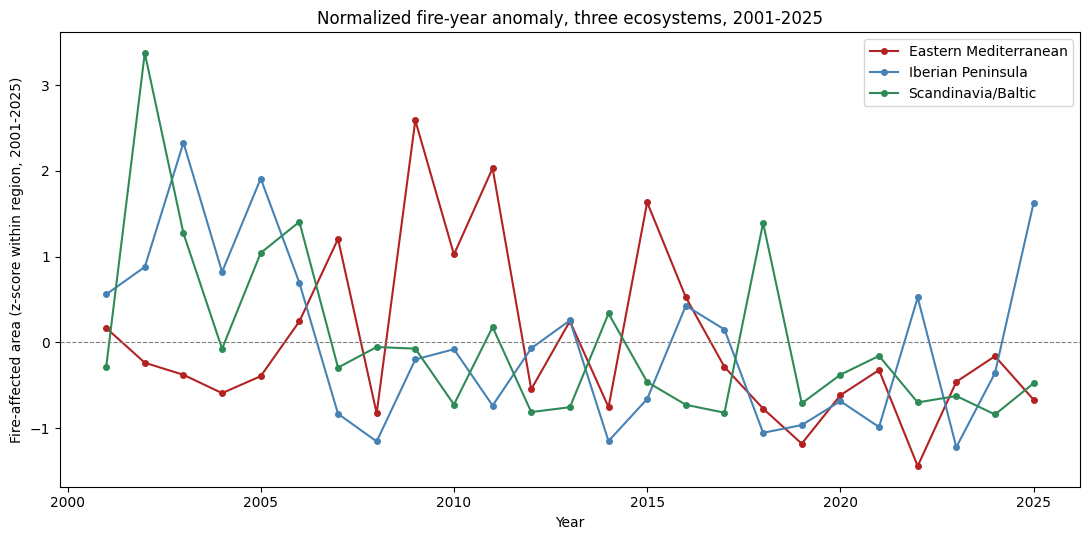

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = {"Eastern Mediterranean": "firebrick", "Iberian Peninsula": "steelblue", "Scandinavia/Baltic": "seagreen"}
for region_name in region_defs:
    sub = df_regions[df_regions["region"] == region_name]
    ax.plot(sub["year"], sub["z"], marker="o", markersize=4, label=region_name, color=colors[region_name])

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Fire-affected area (z-score within region, 2001-2025)")
ax.set_title("Normalized fire-year anomaly, three ecosystems, 2001-2025")
ax.legend()
plt.tight_layout()
plt.savefig("part4_normalized_trend_comparison.png", dpi=150)
plt.show()

# What to look for:
# - Years where all three lines spike together suggest a genuinely
#   continental-scale driver (a hemispheric heat/drought event) rather than
#   region-specific conditions.
# - Years where one region spikes while the others are flat/negative are
#   the more common case in this series so far (2009/2011 Eastern Med,
#   2003/2005/2025 Iberia, 2002/2018 Scandinavia/Baltic don't obviously
#   line up with each other) -- worth checking directly with a simple
#   cross-correlation or just visual inspection once this cell runs.


## 6. Notes for the write-up

- [ ] Section 3's `df_loo` table is now the actual robustness record for
  every sub-region in the series -- check which ones are flagged `fragile`
  beyond just the already-known Baltic case, and update Parts 1-2's
  published text if any of their headline numbers turn out to be fragile
  too.
- [ ] CV vs. GDP, and |r| vs. GDP (Section 4): do the two explanations
  separate at all, or is n too small/confounded to say anything beyond
  "illustrative"?
- [ ] Normalized trend (Section 5): do any years spike across all three
  ecosystems at once? If yes, that's a genuinely new, continental-scale
  finding this series hasn't surfaced before. If no, that itself supports
  the series' recurring theme -- fire activity in these ecosystems is
  driven by regional/local conditions, not a shared continental signal.
- [ ] Revisit the series' running list of methodology lessons as a single
  reference table for this post: Terra orbit drift (Part 1), GAUL name
  verification (Part 2), fixed-window fire-season mismatch (Part 2),
  MODIS resolution floor for contained fires (Part 3), single-year outlier
  fragility (Part 3, confirmed series-wide in Part 4). Worth a standalone
  section -- this list has value to readers doing similar GEE
  region-comparison work, independent of the wildfire subject matter.

## 7. Closing

This is the last notebook in the "Same Fire, Different Ground" series as
currently scoped. What to say here is intentionally left open rather than
drafted in advance -- it's the one section of this series that shouldn't be
templated from the previous three.
